##  Import Required Libraries

In this step, we import all essential libraries required for data analysis, visualization, and machine learning.

- numpy → numerical operations
- pandas → data handling and manipulation
- matplotlib & seaborn → data visualization
- sklearn → machine learning models and preprocessing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## Load Dataset and Initial Inspection

In this step, we load the dataset and perform an initial inspection to understand:

- Number of rows and columns
- Data types of each feature
- First and last few records
- General structure of the dataset

This helps us detect early issues like incorrect data types, missing values, or unexpected formats.

In [2]:
df = pd.read_csv("data/election_2019_data.csv")
df.shape

NameError: name 'pd' is not defined

##  Inspect Dataset Structure

In this step, we explore the dataset in detail to understand:

- Feature names
- Data types
- Missing values
- Sample records

This helps identify issues like:
- Incorrect data types
- Null values
- Categorical vs numerical imbalance

In [ ]:
df.head()

,STATE,CONSTITUENCY,NAME,WINNER,PARTY,SYMBOL,GENDER,CRIMINAL\nCASES,AGE,CATEGORY,EDUCATION,ASSETS,LIABILITIES,GENERAL\nVOTES,POSTAL\nVOTES,TOTAL\nVOTES,OVER TOTAL ELECTORS \nIN CONSTITUENCY,OVER TOTAL VOTES POLLED \nIN CONSTITUENCY,TOTAL ELECTORS
0,Telangana,ADILABAD,SOYAM BAPU RAO,1,BJP,Lotus,MALE,52,52.0,ST,12th Pass,"Rs 30,99,414\n ~ 30 Lacs+","Rs 2,31,450\n ~ 2 Lacs+",376892,482,377374,25.330684,35.468248,1489790
1,Telangana,ADILABAD,Godam Nagesh,0,TRS,Car,MALE,0,54.0,ST,Post Graduate,"Rs 1,84,77,888\n ~ 1 Crore+","Rs 8,47,000\n ~ 8 Lacs+",318665,149,318814,21.399929,29.964370,1489790
2,Telangana,ADILABAD,RATHOD RAMESH,0,INC,Hand,MALE,3,52.0,ST,12th Pass,"Rs 3,64,91,000\n ~ 3 Crore+","Rs 1,53,00,000\n ~ 1 Crore+",314057,181,314238,21.092771,29.534285,1489790
3,Telangana,ADILABAD,NOTA,0,NOTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13030,6,13036,0.875023,1.225214,1489790
4,Uttar Pradesh,AGRA,Satyapal Singh Baghel,1,BJP,Lotus,MALE,5,58.0,SC,Doctorate,"Rs 7,42,74,036\n ~ 7 Crore+","Rs 86,06,522\n ~ 86 Lacs+",644459,2416,646875,33.383823,56.464615,1937690


In [ ]:
df.columns

Index(['STATE', 'CONSTITUENCY', 'NAME', 'WINNER', 'PARTY', 'SYMBOL', 'GENDER',
       'CRIMINAL\nCASES', 'AGE', 'CATEGORY', 'EDUCATION', 'ASSETS',
       'LIABILITIES', 'GENERAL\nVOTES', 'POSTAL\nVOTES', 'TOTAL\nVOTES',
       'OVER TOTAL ELECTORS \nIN CONSTITUENCY',
       'OVER TOTAL VOTES POLLED \nIN CONSTITUENCY', 'TOTAL ELECTORS'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 19 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   STATE                                     2263 non-null   object 
 1   CONSTITUENCY                              2263 non-null   object 
 2   NAME                                      2263 non-null   object 
 3   WINNER                                    2263 non-null   int64  
 4   PARTY                                     2263 non-null   object 
 5   SYMBOL                                    2018 non-null   object 
 6   GENDER                                    2018 non-null   object 
 7   CRIMINAL
CASES                            2018 non-null   object 
 8   AGE                                       2018 non-null   float64
 9   CATEGORY                                  2018 non-null   object 
 10  EDUCATION                           

In [7]:
df.describe(include='all')

,STATE,CONSTITUENCY,NAME,WINNER,PARTY,SYMBOL,GENDER,CRIMINAL\nCASES,AGE,CATEGORY,EDUCATION,ASSETS,LIABILITIES,GENERAL\nVOTES,POSTAL\nVOTES,TOTAL\nVOTES,OVER TOTAL ELECTORS \nIN CONSTITUENCY,OVER TOTAL VOTES POLLED \nIN CONSTITUENCY,TOTAL ELECTORS
count,2263,2263,2263,2263.000000,2263,2018,2018,2018,2018.000000,2018,2018,2018,2018,2.263000e+03,2263.000000,2.263000e+03,2263.000000,2263.000000,2.263000e+03
unique,36,539,2014,NaN,133,126,2,29,NaN,3,13,1979,1226,NaN,NaN,NaN,NaN,NaN,NaN
top,Uttar Pradesh,AURANGABAD,NOTA,NaN,BJP,Lotus,MALE,0,NaN,GENERAL,Post Graduate,Not Available,Rs 0\n ~,NaN,NaN,NaN,NaN,NaN,NaN
freq,274,14,245,NaN,420,420,1760,1242,NaN,1392,502,22,634,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.238179,NaN,NaN,NaN,NaN,52.273538,NaN,NaN,NaN,NaN,2.615991e+05,990.710561,2.625898e+05,15.811412,23.190525,1.658016e+06
std,NaN,NaN,NaN,0.426064,NaN,NaN,NaN,NaN,11.869373,NaN,NaN,NaN,NaN,2.549906e+05,1602.839174,2.559822e+05,14.962861,21.564758,3.145187e+05
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,1.339000e+03,0.000000,1.342000e+03,0.097941,1.000039,5.518900e+04
25%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,43.250000,NaN,NaN,NaN,NaN,2.103450e+04,57.000000,2.116250e+04,1.296518,1.899502,1.530014e+06
50%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,1.539340e+05,316.000000,1.544890e+05,10.510553,16.221721,1.679030e+06
75%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,61.000000,NaN,NaN,NaN,NaN,4.858040e+05,1385.000000,4.872315e+05,29.468185,42.590233,1.816857e+06


In [8]:
df.isnull().sum()

STATE                                          0
CONSTITUENCY                                   0
NAME                                           0
WINNER                                         0
PARTY                                          0
SYMBOL                                       245
GENDER                                       245
CRIMINAL\nCASES                              245
AGE                                          245
CATEGORY                                     245
EDUCATION                                    245
ASSETS                                       245
LIABILITIES                                  245
GENERAL\nVOTES                                 0
POSTAL\nVOTES                                  0
TOTAL\nVOTES                                   0
OVER TOTAL ELECTORS \nIN CONSTITUENCY          0
OVER TOTAL VOTES POLLED \nIN CONSTITUENCY      0
TOTAL ELECTORS                                 0
dtype: int64

## Basic Cleaning Before EDA

Before performing Exploratory Data Analysis (EDA), we fix critical structural issues:

- Remove newline characters from column names
- Standardize column naming
- Ensure easier access to features

This step ensures that EDA results are accurate and meaningful.

In [9]:
df.columns = df.columns.str.replace('\n', ' ')
df.columns = df.columns.str.replace('  ', ' ')
df.columns = df.columns.str.strip()

df.columns

Index(['STATE', 'CONSTITUENCY', 'NAME', 'WINNER', 'PARTY', 'SYMBOL', 'GENDER',
       'CRIMINAL CASES', 'AGE', 'CATEGORY', 'EDUCATION', 'ASSETS',
       'LIABILITIES', 'GENERAL VOTES', 'POSTAL VOTES', 'TOTAL VOTES',
       'OVER TOTAL ELECTORS IN CONSTITUENCY',
       'OVER TOTAL VOTES POLLED IN CONSTITUENCY', 'TOTAL ELECTORS'],
      dtype='object')

In [10]:
df.head()

,STATE,CONSTITUENCY,NAME,WINNER,PARTY,SYMBOL,GENDER,CRIMINAL CASES,AGE,CATEGORY,EDUCATION,ASSETS,LIABILITIES,GENERAL VOTES,POSTAL VOTES,TOTAL VOTES,OVER TOTAL ELECTORS IN CONSTITUENCY,OVER TOTAL VOTES POLLED IN CONSTITUENCY,TOTAL ELECTORS
0,Telangana,ADILABAD,SOYAM BAPU RAO,1,BJP,Lotus,MALE,52,52.0,ST,12th Pass,"Rs 30,99,414\n ~ 30 Lacs+","Rs 2,31,450\n ~ 2 Lacs+",376892,482,377374,25.330684,35.468248,1489790
1,Telangana,ADILABAD,Godam Nagesh,0,TRS,Car,MALE,0,54.0,ST,Post Graduate,"Rs 1,84,77,888\n ~ 1 Crore+","Rs 8,47,000\n ~ 8 Lacs+",318665,149,318814,21.399929,29.964370,1489790
2,Telangana,ADILABAD,RATHOD RAMESH,0,INC,Hand,MALE,3,52.0,ST,12th Pass,"Rs 3,64,91,000\n ~ 3 Crore+","Rs 1,53,00,000\n ~ 1 Crore+",314057,181,314238,21.092771,29.534285,1489790
3,Telangana,ADILABAD,NOTA,0,NOTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13030,6,13036,0.875023,1.225214,1489790
4,Uttar Pradesh,AGRA,Satyapal Singh Baghel,1,BJP,Lotus,MALE,5,58.0,SC,Doctorate,"Rs 7,42,74,036\n ~ 7 Crore+","Rs 86,06,522\n ~ 86 Lacs+",644459,2416,646875,33.383823,56.464615,1937690


##  Target Variable Analysis

We analyze the distribution of the target variable (WINNER).

This helps us understand:
- Class imbalance
- Proportion of winners vs non-winners
- Whether special techniques are needed (like balancing)

In [11]:
df['WINNER'].value_counts()

WINNER
0    1724
1     539
Name: count, dtype: int64

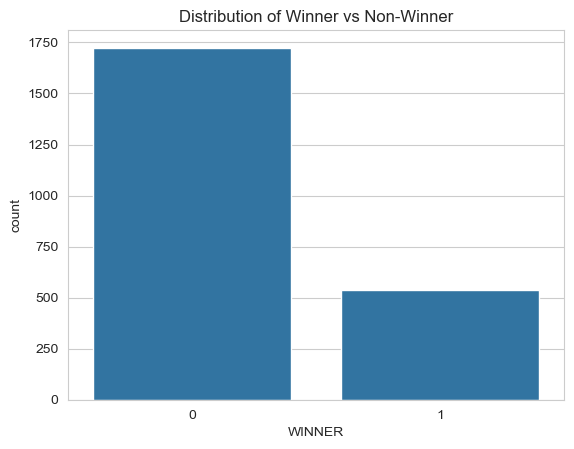

In [12]:
sns.countplot(x='WINNER', data=df)
plt.title("Distribution of Winner vs Non-Winner")
plt.show()

## Step 5: Categorical Feature Analysis

We analyze important categorical features to understand their relationship with the target variable.

This helps identify patterns such as:
- Which party wins more
- Gender distribution
- Category influence

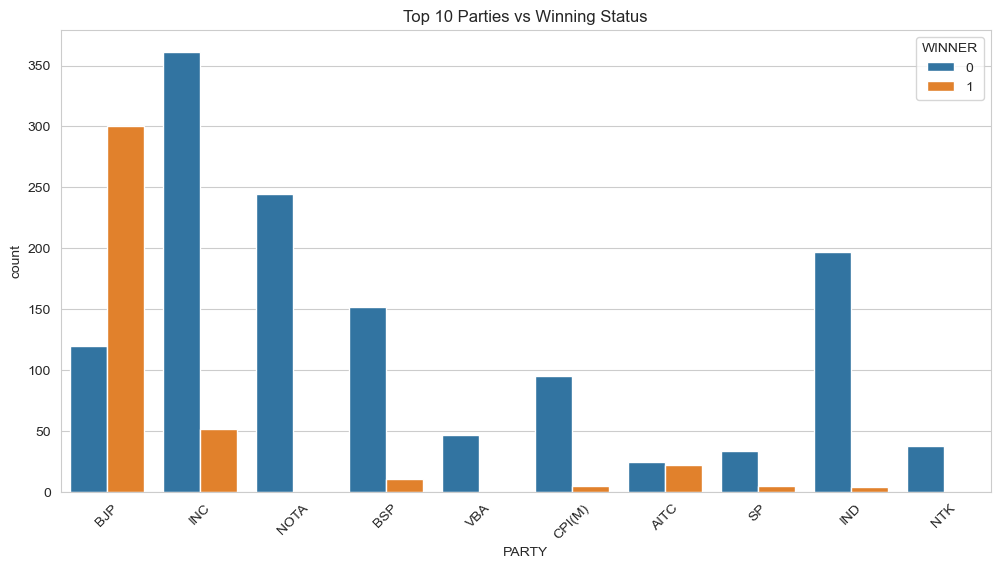

In [16]:
top_parties = df['PARTY'].value_counts().head(10).index

filtered_df = df[df['PARTY'].isin(top_parties)]

plt.figure(figsize=(12,6))
sns.countplot(x='PARTY', hue='WINNER', data=filtered_df)
plt.xticks(rotation=45)
plt.title("Top 10 Parties vs Winning Status")
plt.show()

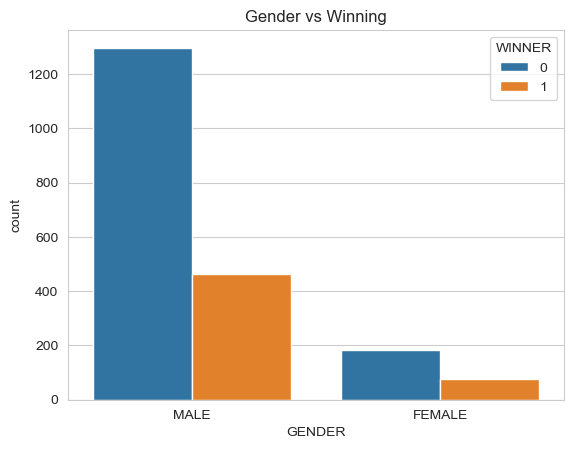

In [14]:
sns.countplot(x='GENDER', hue='WINNER', data=df)
plt.title("Gender vs Winning")
plt.show()

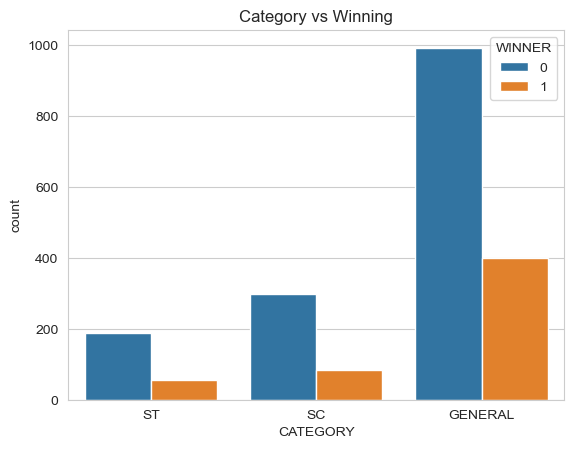

In [15]:
sns.countplot(x='CATEGORY', hue='WINNER', data=df)
plt.title("Category vs Winning")
plt.show()

##  Data Cleaning and Preprocessing

In this step, we clean the dataset to make it suitable for machine learning.

Tasks performed:
- Remove irrelevant entries (NOTA)
- Handle missing values
- Convert object columns to numeric
- Drop unnecessary columns

In [19]:
df = df[df['NAME'] != 'NOTA']

df.shape

(2018, 19)

In [20]:
df = df.drop(['NAME', 'SYMBOL'], axis=1)

In [21]:
df['CRIMINAL CASES'] = pd.to_numeric(df['CRIMINAL CASES'], errors='coerce')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2018 entries, 0 to 2261
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   STATE                                    2018 non-null   object 
 1   CONSTITUENCY                             2018 non-null   object 
 2   WINNER                                   2018 non-null   int64  
 3   PARTY                                    2018 non-null   object 
 4   GENDER                                   2018 non-null   object 
 5   CRIMINAL CASES                           1996 non-null   float64
 6   AGE                                      2018 non-null   float64
 7   CATEGORY                                 2018 non-null   object 
 8   EDUCATION                                2018 non-null   object 
 9   ASSETS                                   2018 non-null   object 
 10  LIABILITIES                              2018 non-nul

##  Converting Financial Columns to Numeric

The ASSETS and LIABILITIES columns are currently stored as text with currency symbols and formatting.

We clean and convert them into numeric values so they can be used for analysis and modeling.

In [23]:
import re

def clean_money(value):
    if pd.isnull(value):
        return np.nan
    value = str(value)
    value = re.sub(r'[^\d]', '', value)
    if value == '':
        return np.nan
    return int(value)

df['ASSETS'] = df['ASSETS'].apply(clean_money)
df['LIABILITIES'] = df['LIABILITIES'].apply(clean_money)

In [24]:
df[['ASSETS', 'LIABILITIES']].head()

,ASSETS,LIABILITIES
0,3.099414e+08,2314502.0
1,1.847789e+08,8470008.0
2,3.649100e+08,153000001.0
4,7.427404e+08,860652286.0
5,1.337844e+10,222518912.0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2018 entries, 0 to 2261
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   STATE                                    2018 non-null   object 
 1   CONSTITUENCY                             2018 non-null   object 
 2   WINNER                                   2018 non-null   int64  
 3   PARTY                                    2018 non-null   object 
 4   GENDER                                   2018 non-null   object 
 5   CRIMINAL CASES                           1996 non-null   float64
 6   AGE                                      2018 non-null   float64
 7   CATEGORY                                 2018 non-null   object 
 8   EDUCATION                                2018 non-null   object 
 9   ASSETS                                   1992 non-null   float64
 10  LIABILITIES                              1995 non-nul

## Numerical Feature Analysis

We analyze how key numerical features influence the probability of winning.

Focus features:
- AGE
- ASSETS
- LIABILITIES
- CRIMINAL CASES

We use distribution plots and KDE to understand patterns.

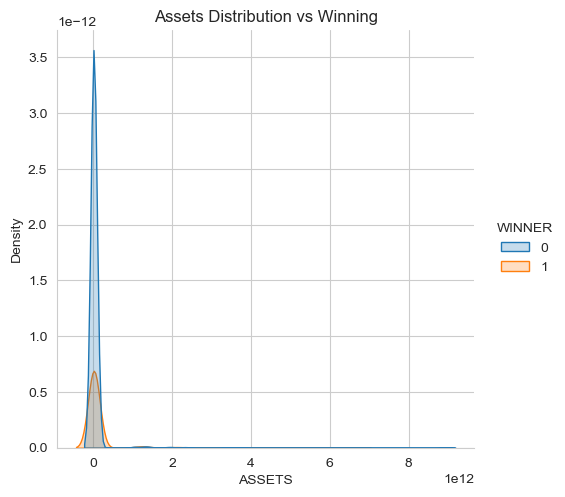

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(data=df, x="ASSETS", hue="WINNER", kind="kde", fill=True)
plt.title("Assets Distribution vs Winning")
plt.show()

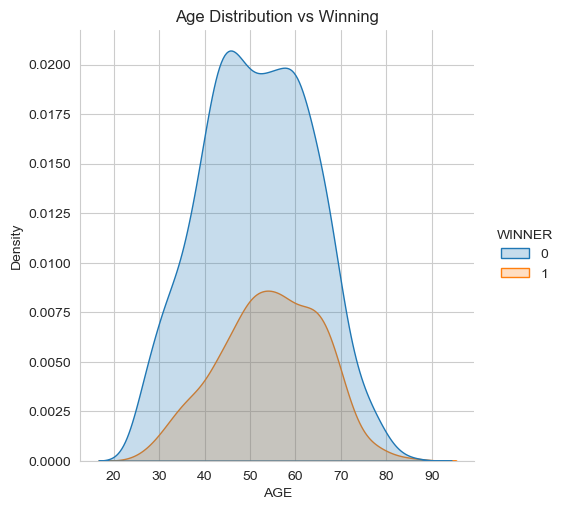

In [27]:
sns.displot(data=df, x="AGE", hue="WINNER", kind="kde", fill=True)
plt.title("Age Distribution vs Winning")
plt.show()

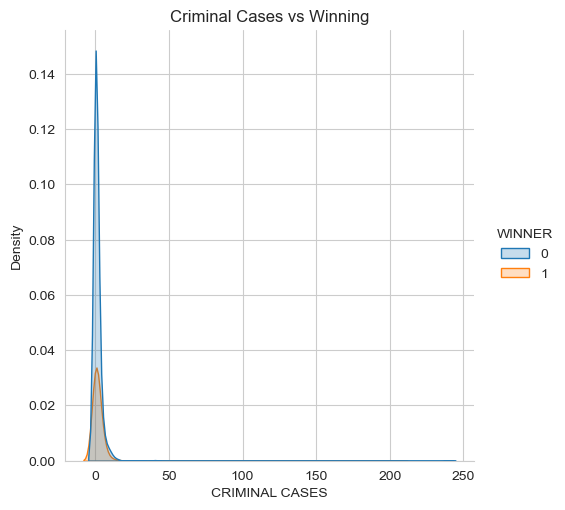

In [28]:
sns.displot(data=df, x="CRIMINAL CASES", hue="WINNER", kind="kde", fill=True)
plt.title("Criminal Cases vs Winning")
plt.show()

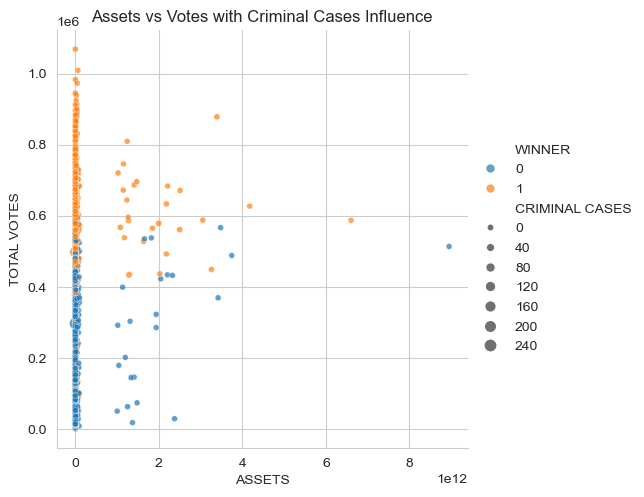

In [29]:
sns.relplot(
    data=df,
    x="ASSETS",
    y="TOTAL VOTES",
    hue="WINNER",
    size="CRIMINAL CASES",
    alpha=0.7
)
plt.title("Assets vs Votes with Criminal Cases Influence")
plt.show()

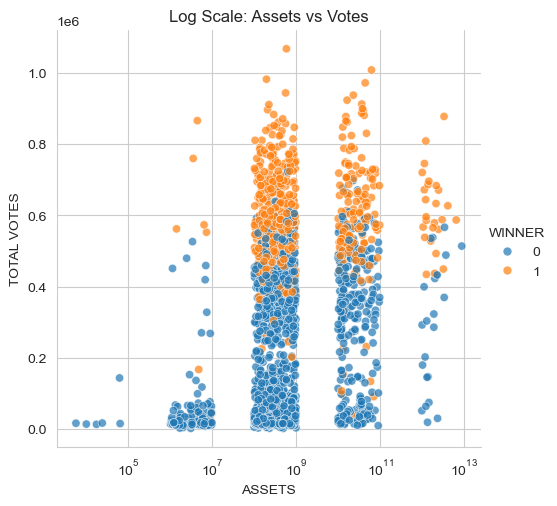

In [30]:
sns.relplot(
    data=df,
    x="ASSETS",
    y="TOTAL VOTES",
    hue="WINNER",
    alpha=0.7
)
plt.xscale('log')
plt.title("Log Scale: Assets vs Votes")
plt.show()

## Advanced Distribution Analysis

We use advanced statistical plots to deeply understand feature distributions and compare winners vs non-winners.

Focus:
- ECDF → cumulative behavior
- Histogram → frequency patterns
- KDE → density comparison

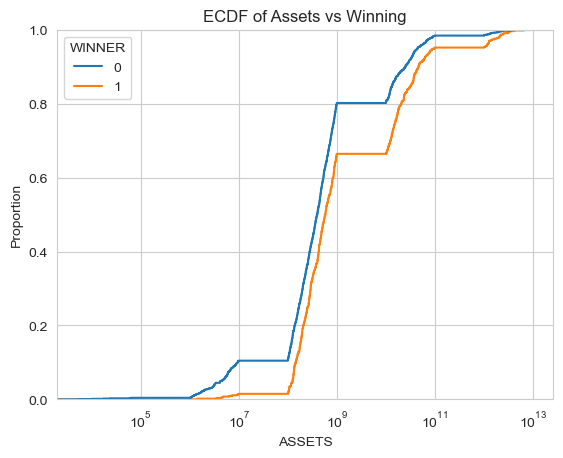

In [32]:
sns.ecdfplot(data=df, x="ASSETS", hue="WINNER")
plt.xscale('log')
plt.title("ECDF of Assets vs Winning")
plt.show()

C:\Users\SOMUJIT\AppData\Local\Temp\ipykernel_2828\6929336.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['LOG_ASSETS'] = np.log1p(df_filtered['ASSETS'])


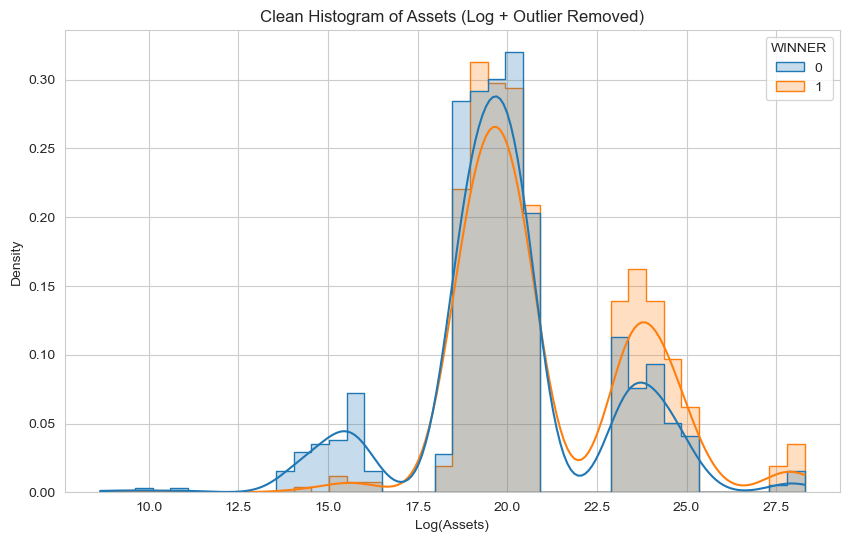

In [35]:
import numpy as np

# remove extreme outliers (top 1%)
upper_limit = df['ASSETS'].quantile(0.99)
df_filtered = df[df['ASSETS'] <= upper_limit]

# log transform
df_filtered['LOG_ASSETS'] = np.log1p(df_filtered['ASSETS'])

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_filtered,
    x='LOG_ASSETS',
    hue='WINNER',
    bins=40,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Clean Histogram of Assets (Log + Outlier Removed)")
plt.xlabel("Log(Assets)")
plt.ylabel("Density")

plt.show()

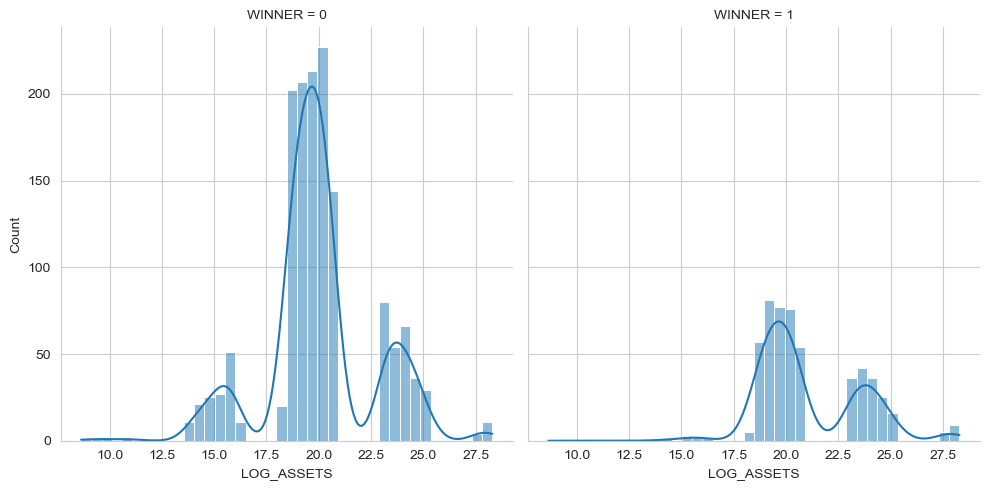

In [36]:
sns.displot(
    data=df_filtered,
    x="LOG_ASSETS",
    col="WINNER",
    bins=40,
    kde=True
)

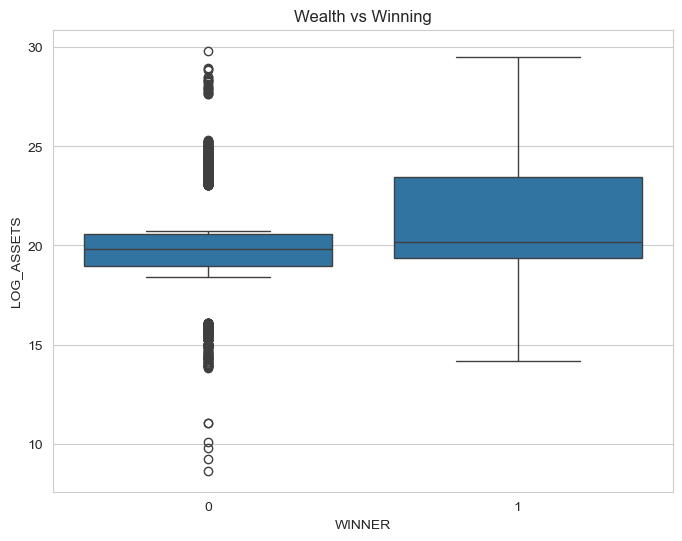

In [38]:
plt.figure(figsize=(8,6))
sns.boxplot(x='WINNER', y='LOG_ASSETS', data=df)
plt.title("Wealth vs Winning")
plt.show()

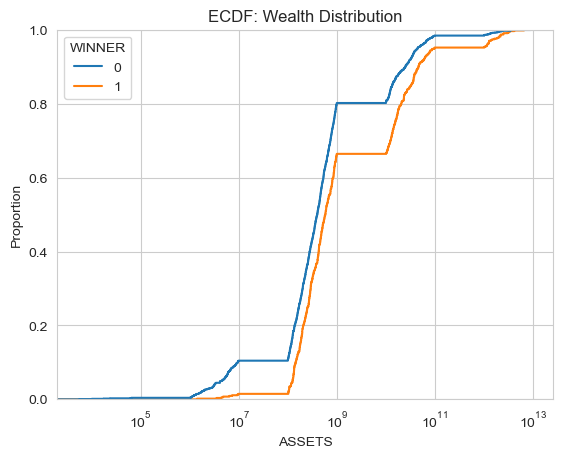

In [39]:
sns.ecdfplot(data=df, x="ASSETS", hue="WINNER")
plt.xscale('log')
plt.title("ECDF: Wealth Distribution")
plt.show()

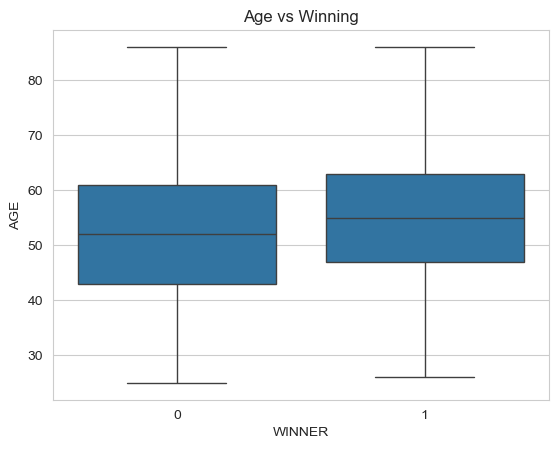

In [40]:
sns.boxplot(x='WINNER', y='AGE', data=df)
plt.title("Age vs Winning")
plt.show()

## EDA 3: Criminal Cases vs Winning

We examine whether candidates with criminal records have different winning probabilities.

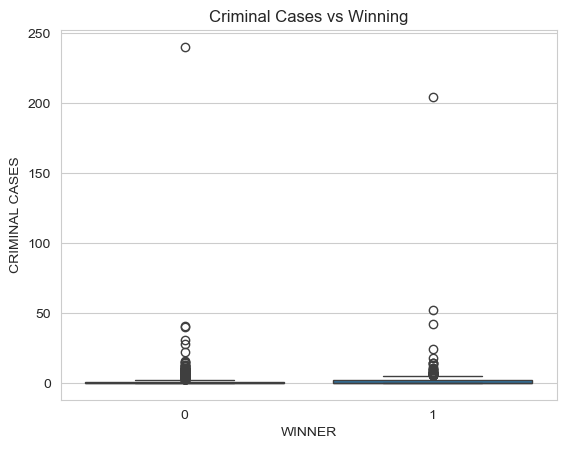

In [41]:
sns.boxplot(x='WINNER', y='CRIMINAL CASES', data=df)
plt.title("Criminal Cases vs Winning")
plt.show()

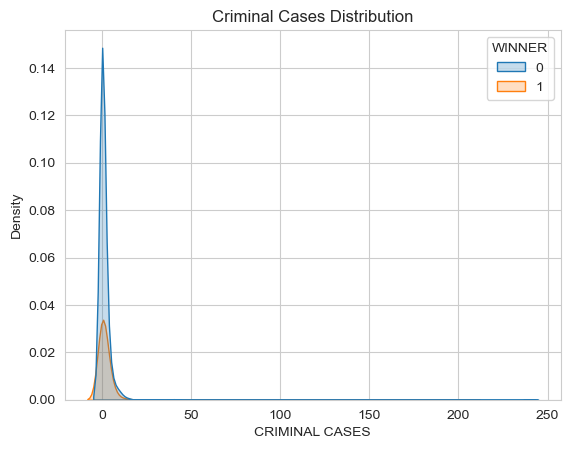

In [42]:
sns.kdeplot(data=df, x="CRIMINAL CASES", hue="WINNER", fill=True)
plt.title("Criminal Cases Distribution")
plt.show()

## EDA 4: Votes vs Winning

We analyze how vote count and vote share relate to winning.

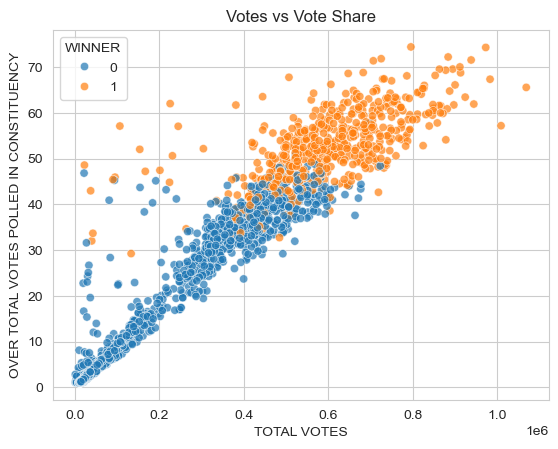

In [43]:
sns.scatterplot(
    data=df,
    x="TOTAL VOTES",
    y="OVER TOTAL VOTES POLLED IN CONSTITUENCY",
    hue="WINNER",
    alpha=0.7
)
plt.title("Votes vs Vote Share")
plt.show()

## EDA 5: Correlation Analysis

We examine relationships between numerical features.

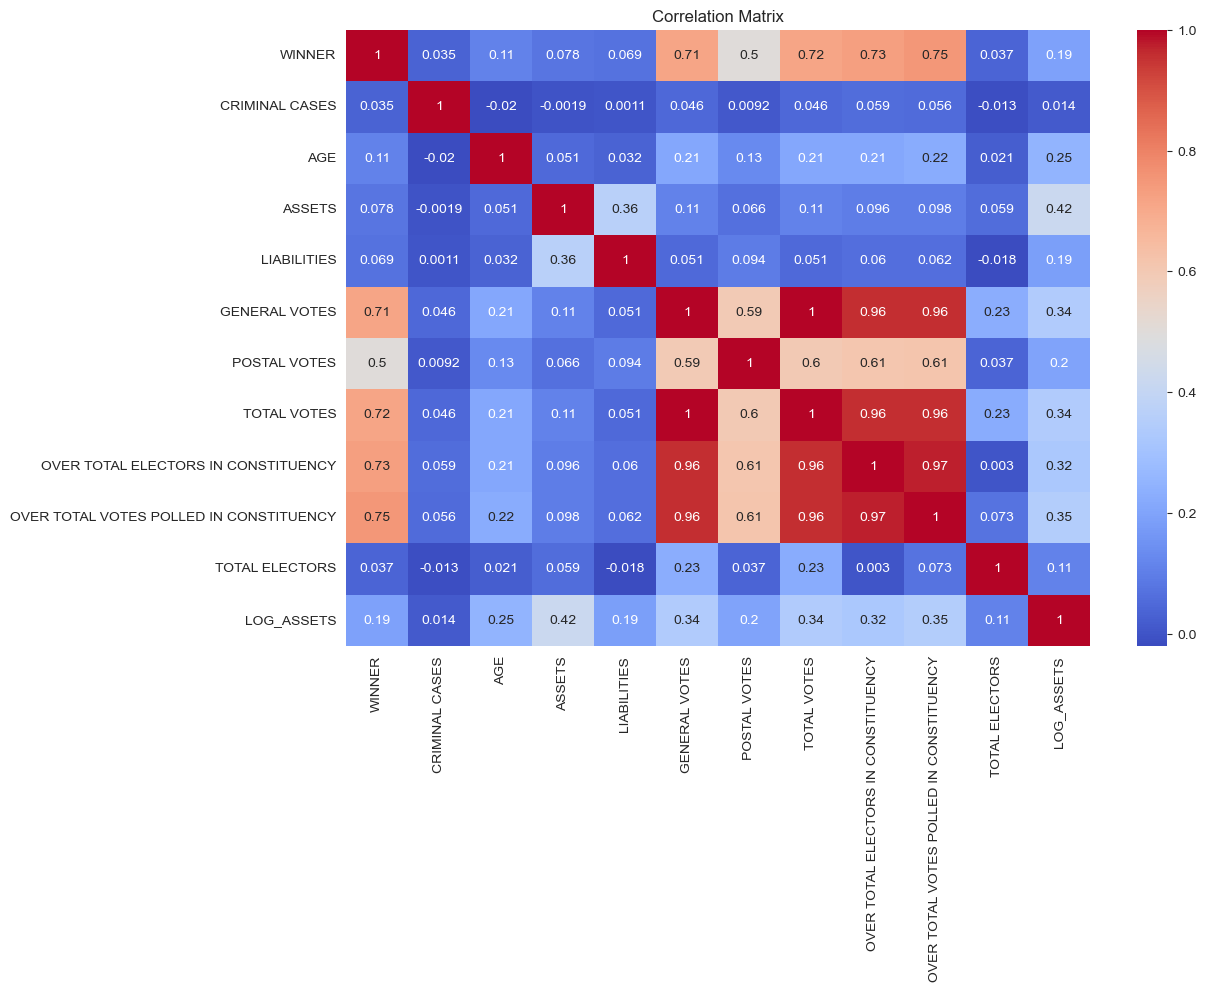

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

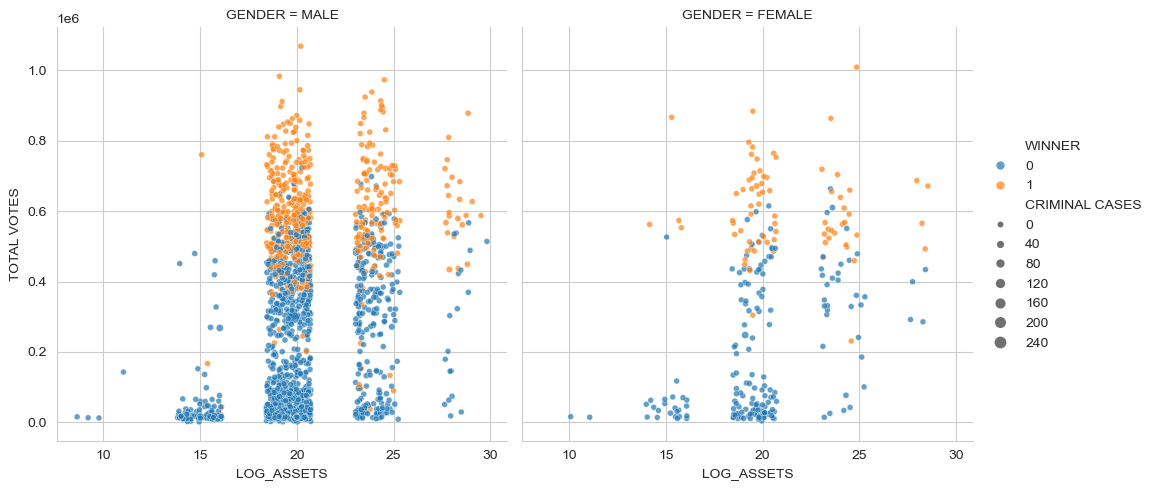

In [45]:
sns.relplot(
    data=df,
    x="LOG_ASSETS",
    y="TOTAL VOTES",
    hue="WINNER",
    size="CRIMINAL CASES",
    col="GENDER",
    alpha=0.7
)
plt.show()